In [1]:
!pip install textblob vaderSentiment wordcloud seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 8.9 MB/s eta 0:00:00


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

In [4]:
df = pd.read_csv('/content/Student_Satisfaction_Survey.csv', encoding='ISO-8859-1')
df.head()

,SN,Total Feedback Given,Total Configured,Questions,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5,Average/ Percentage,Course Name,Basic Course
0,1,1,12,How much of the syllabus was covered in the cl...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
1,2,1,12,How well did the teachers prepare for the clas...,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
2,3,1,12,How well were the teachers able to communicate?,0,0,0,0,1,5.00 / 100.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
3,4,1,12,The teachers approach to teaching can best be...,0,0,1,0,0,3.00 / 60.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY
4,5,1,12,Fairness of the internal evaluation process by...,0,0,0,1,0,4.00 / 80.00,FY B.VOC FOOD TECHNOLOGY,B.VOC FOOD TECHNOLOGY


In [5]:
print(df.columns)

Index(['SN', 'Total Feedback Given', 'Total Configured', 'Questions',
       'Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4',
       'Weightage 5', 'Average/ Percentage', 'Course Name ', 'Basic Course'],
      dtype='object')


In [7]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [8]:
print(df.isnull().sum())

SN                      0
Total Feedback Given    0
Total Configured        0
Questions               0
Weightage 1             0
Weightage 2             0
Weightage 3             0
Weightage 4             0
Weightage 5             0
Average/ Percentage     0
Course Name             0
Basic Course            0
dtype: int64


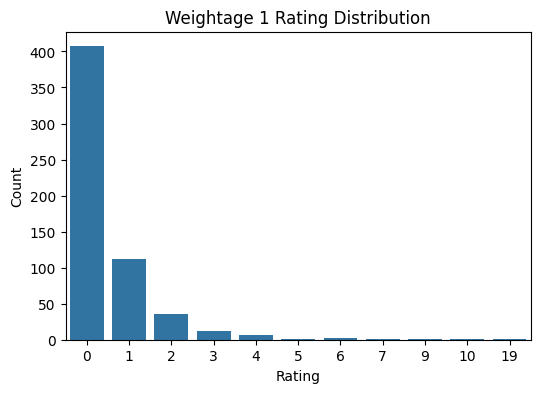

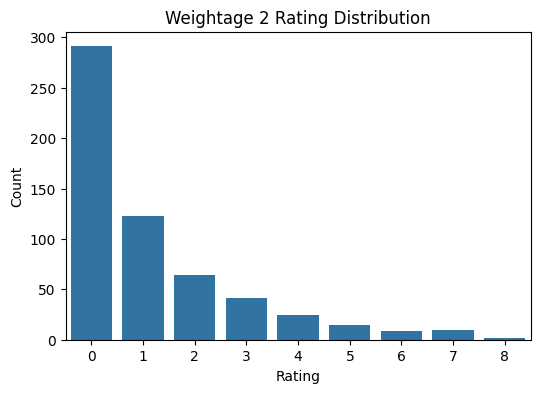

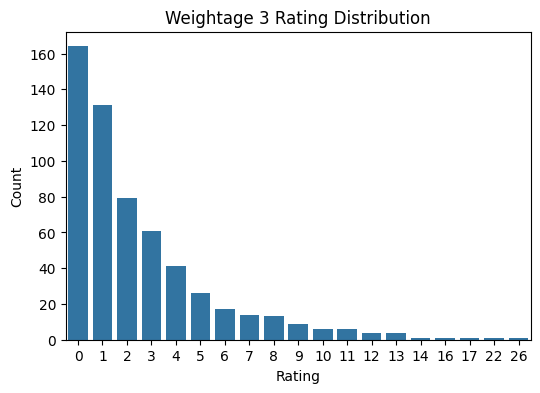

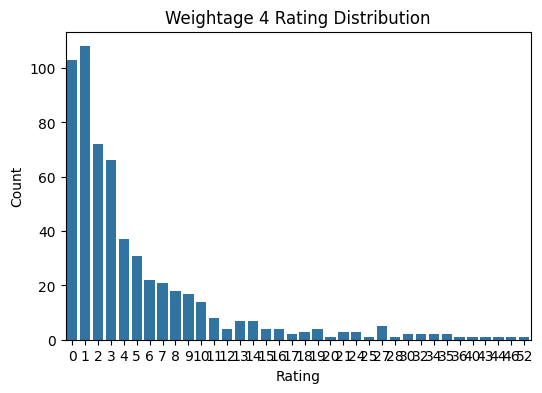

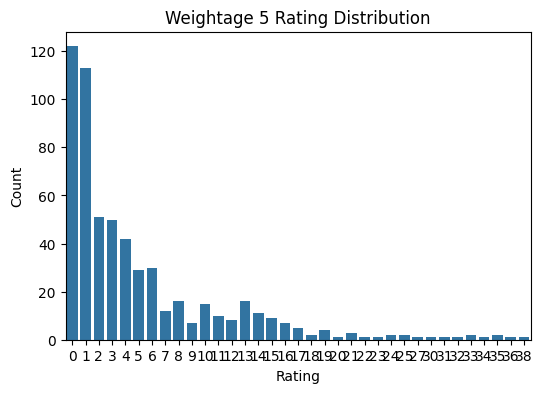

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

for col in ['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f'{col} Rating Distribution')
    plt.xlabel('Rating')
    plt.ylabel('Count')
    plt.show()

In [10]:
for col in ['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']:
    avg = df[col].mean()
    print(f"Average rating for {col}: {avg:.2f}")

Average rating for Weightage 1: 0.53
Average rating for Weightage 2: 1.19
Average rating for Weightage 3: 2.54
Average rating for Weightage 4: 5.08
Average rating for Weightage 5: 4.97


In [12]:
print(df.columns)

Index(['SN', 'Total Feedback Given', 'Total Configured', 'Questions',
       'Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4',
       'Weightage 5', 'Average/ Percentage', 'Course Name ', 'Basic Course'],
      dtype='object')


In [13]:
df.groupby('Course Name ')[['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']].mean()

,Weightage 1,Weightage 2,Weightage 3,Weightage 4,Weightage 5
Course Name,,,,,
FY B.VOC FOOD TECHNOLOGY,0.00,0.15,0.45,0.25,0.15
FY BCOM (ACCOUNTING & FINANCE),1.95,3.40,11.00,32.55,25.10
FY BCOM (BANKING & INSURANCE),0.60,0.75,1.15,6.05,11.45
FYBA,0.00,0.00,0.05,0.35,0.60
FYBMS,1.05,1.55,3.75,7.85,11.80
FYBSC,0.45,1.30,2.00,4.55,3.70
M.SC PART - 1 COMPUTER SCIENCE,0.20,0.55,1.15,1.40,0.70
M.SC PART - 2 COMPUTER SCIENCE,0.05,0.15,0.80,3.15,2.85
MA PSYCHOLOGY - 1,0.00,0.15,1.70,2.50,0.65


In [15]:
print(df.columns)

Index(['SN', 'Total Feedback Given', 'Total Configured', 'Questions',
       'Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4',
       'Weightage 5', 'Average/ Percentage', 'Course Name ', 'Basic Course'],
      dtype='object')


In [16]:
df.columns = df.columns.str.strip()

In [17]:
df_grouped = df.groupby('Course Name')[['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']].mean()

print(df_grouped)

                                  Weightage 1  Weightage 2  Weightage 3  \
Course Name                                                               
FY B.VOC FOOD TECHNOLOGY                 0.00         0.15         0.45   
FY BCOM (ACCOUNTING & FINANCE)           1.95         3.40        11.00   
FY BCOM (BANKING & INSURANCE)            0.60         0.75         1.15   
FYBA                                     0.00         0.00         0.05   
FYBMS                                    1.05         1.55         3.75   
FYBSC                                    0.45         1.30         2.00   
M.SC PART - 1 COMPUTER SCIENCE           0.20         0.55         1.15   
M.SC PART - 2 COMPUTER SCIENCE           0.05         0.15         0.80   
MA PSYCHOLOGY - 1                        0.00         0.15         1.70   
MA PSYCHOLOGY - 3                        0.45         0.90         2.30   
MSC ANALYTICAL CHEMISTRY SEM I           0.00         0.00         0.25   
MSC ANALYTICAL CHEMISTRY 

/tmp/ipython-input-1834612735.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_courses.index, y=top_courses['Weightage 5'], palette="viridis")


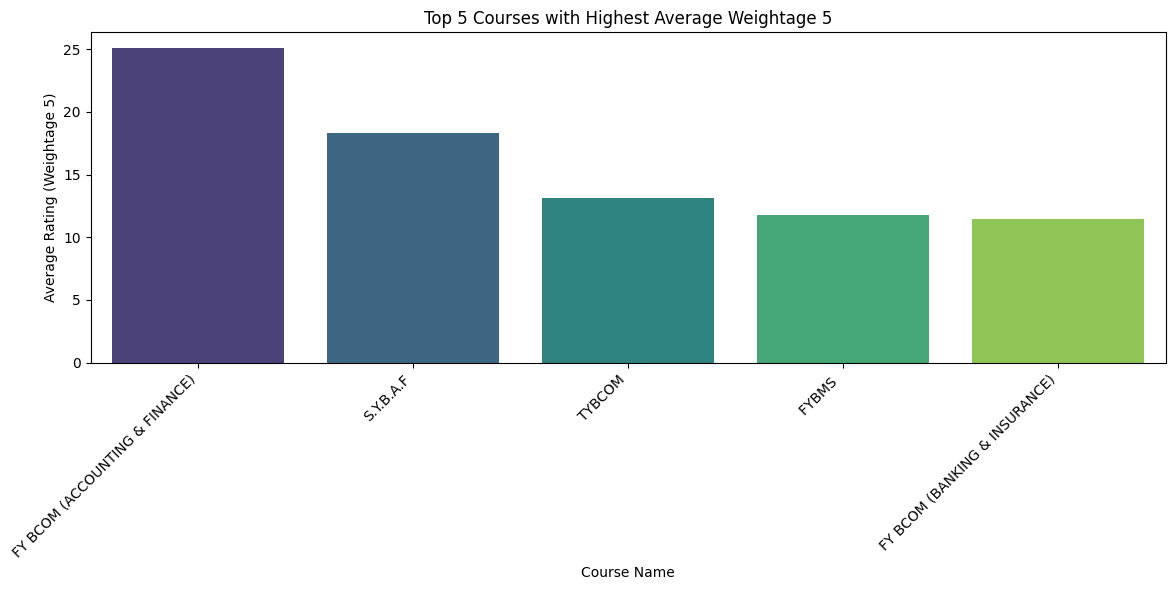

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Top 5 courses overall by Weightage 5 average
top_courses = df_grouped.sort_values('Weightage 5', ascending=False).head(5)

plt.figure(figsize=(12,6))
sns.barplot(x=top_courses.index, y=top_courses['Weightage 5'], palette="viridis")
plt.title('Top 5 Courses with Highest Average Weightage 5')
plt.xlabel('Course Name')
plt.ylabel('Average Rating (Weightage 5)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [21]:
df.columns = df.columns.str.strip()

In [22]:
grouped_df = df.groupby('Course Name')[
    ['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']
].sum()

In [24]:
df.columns = df.columns.str.strip()

In [25]:
grouped_df = df.groupby('Course Name')[
    ['Weightage 1', 'Weightage 2', 'Weightage 3', 'Weightage 4', 'Weightage 5']
].sum()

In [26]:
print(grouped_df)

                                  Weightage 1  Weightage 2  Weightage 3  \
Course Name                                                               
FY B.VOC FOOD TECHNOLOGY                    0            3            9   
FY BCOM (ACCOUNTING & FINANCE)             39           68          220   
FY BCOM (BANKING & INSURANCE)              12           15           23   
FYBA                                        0            0            1   
FYBMS                                      21           31           75   
FYBSC                                       9           26           40   
M.SC PART - 1 COMPUTER SCIENCE              4           11           23   
M.SC PART - 2 COMPUTER SCIENCE              1            3           16   
MA PSYCHOLOGY - 1                           0            3           34   
MA PSYCHOLOGY - 3                           9           18           46   
MSC ANALYTICAL CHEMISTRY SEM I              0            0            5   
MSC ANALYTICAL CHEMISTRY 

##  Key Insights & Recommendations

 *Top-performing courses based on total student ratings:*
- *FY BCOM (ACCOUNTING & FINANCE), **TYBCOM, and **S.Y.B.A.F* received the highest cumulative ratings across all weightages, showing strong overall student satisfaction.
- *SYBCOM* and *FYBMS* also performed well, especially in Weightage 4 and 5.

 *Courses with low feedback engagement or satisfaction:*
- Courses like *MSC INFORMATION TECHNOLOGY - 1, **FYBA, and **MSC PHYSICS - 3* received fewer ratings, suggesting limited participation or possible dissatisfaction.

 *Trends Observed:*
- Commerce stream courses (BCOM, BAF, BMS) consistently outperformed others in higher weightages.
- Science stream postgraduate courses have mixed feedback — some (like MSC Organic Chemistry) performed well, others (like MSC Data Science - 3) had minimal ratings.

 *Suggestion:*
- Future feedback forms should include *text comment sections* to enable sentiment analysis and deeper feedback understanding.

 *Note:* No textual feedback was available in this dataset. Therefore, sentiment analysis via NLP could not be conducted.